In [62]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd 
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt

In [23]:
df=pd.read_csv('gas_cleann.csv')
X = df[['year', 'month']]                
y = df['value_normalized']

In [26]:
model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

In [27]:
model.fit(X_train, y_train, 
          eval_set=[(X_test, y_test)], 
          verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.85
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'rmse'


In [28]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)          
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
r2 = r2_score(y_test_original, y_pred)

In [32]:
df = df.sort_values(['year', 'month']).reset_index(drop=True)

# Lag Features أقل + ميزات إضافية
for lag in [1, 2, 3]:
    df[f'lag_{lag}'] = df['value_normalized'].shift(lag)

df = df.dropna().reset_index(drop=True)

df['year_month'] = df['year'] * 12 + df['month']
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

features = ['year', 'month', 'year_month', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3']
X = df[features]
y = df['value_normalized']

# تحويل أقوى للـ Target
y_transformed = np.log1p(y * 100)   # نضرب في 100 لتكبير القيم قليلاً قبل اللوغاريتم

X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    tree_method='hist'
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_trans = model.predict(X_test)
y_pred = np.expm1(y_pred_trans) / 100
y_test_orig = np.expm1(y_test) / 100

mae = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2 = r2_score(y_test_orig, y_pred)

print("="*60)
print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R²   : {r2:.4f}")
print("="*60)

MAE  : 0.00840
RMSE : 0.04184
R²   : 0.0008


عدد الشهور الفريدة: 121

أول 10 صفوف بعد إنشاء Lags الشهرية:
        date  year  month  value_normalized     lag_1     lag_2     lag_3
0 2015-01-01  2015      1          0.011175  0.009550  0.008374  0.006714
1 2015-02-01  2015      2          0.010505  0.011175  0.009550  0.008374
2 2015-03-01  2015      3          0.009231  0.010505  0.011175  0.009550
3 2015-04-01  2015      4          0.007077  0.009231  0.010505  0.011175
4 2015-05-01  2015      5          0.006515  0.007077  0.009231  0.010505
5 2015-06-01  2015      6          0.006682  0.006515  0.007077  0.009231
6 2015-07-01  2015      7          0.007291  0.006682  0.006515  0.007077
7 2015-08-01  2015      8          0.007235  0.007291  0.006682  0.006515
8 2015-09-01  2015      9          0.006684  0.007235  0.007291  0.006682
9 2015-10-01  2015     10          0.006993  0.006684  0.007235  0.007291


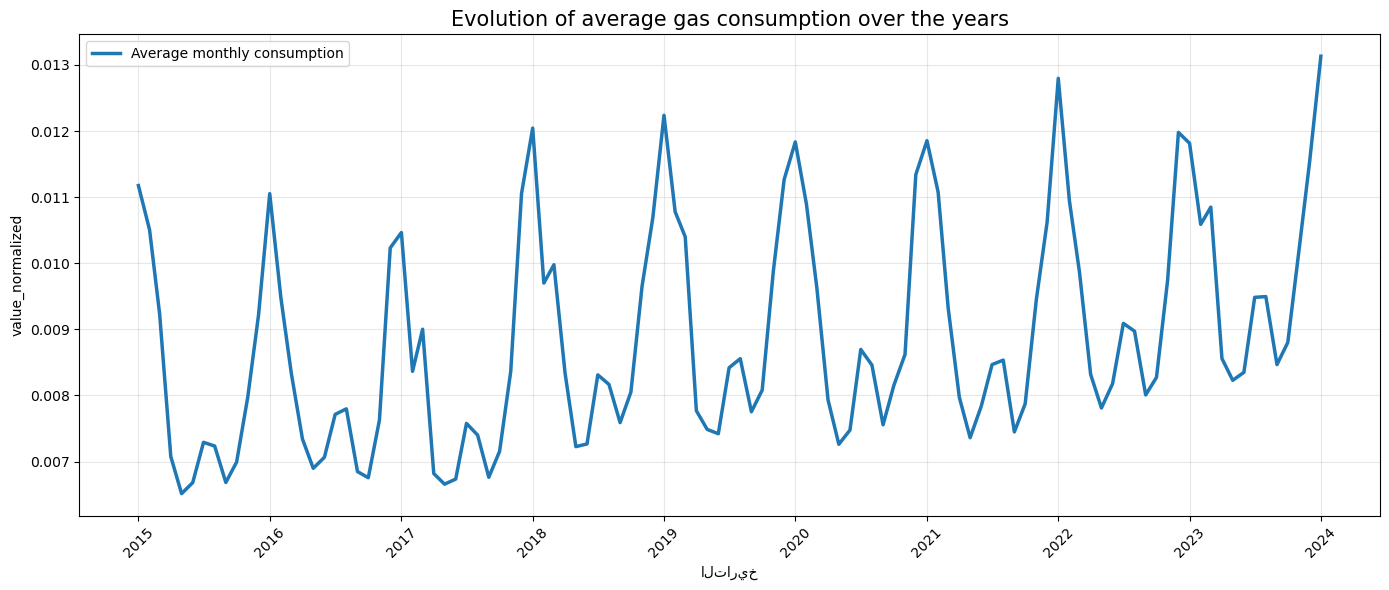

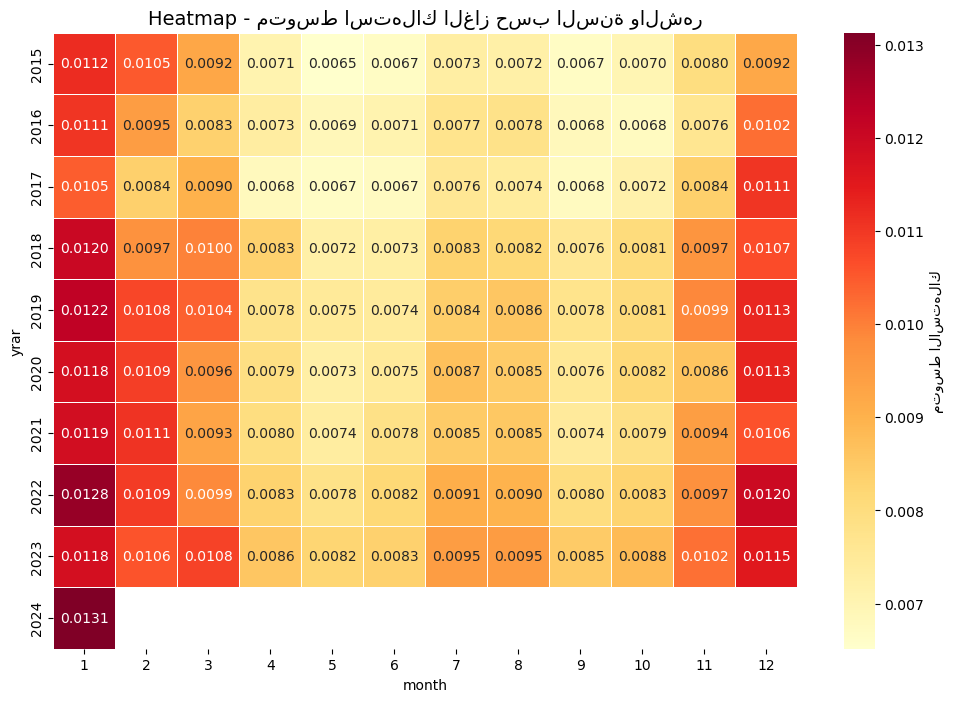

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تحميل وتحضير الداتا 
df = pd.read_csv('gas_cleann.csv')

# إنشاء عمود تاريخ
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')

# حساب المتوسط الشهري (هذا أهم شيء)
monthly = df.groupby(['date', 'year', 'month'])['value_normalized'].agg(['mean', 'count', 'std']).reset_index()
monthly = monthly.rename(columns={'mean': 'value_normalized'})

print(f"عدد الشهور الفريدة: {len(monthly)}")

 # Lags
monthly = monthly.sort_values('date')

for lag in [1, 2, 3, 6, 12]:
    monthly[f'lag_{lag}'] = monthly['value_normalized'].shift(lag)

# حذف الصفوف التي بها NaN في البداية
monthly = monthly.dropna().reset_index(drop=True)

print("\nأول 10 صفوف بعد إنشاء Lags الشهرية:")
print(monthly[['date', 'year', 'month', 'value_normalized', 'lag_1', 'lag_2', 'lag_3']].head(10))

# ====================== 3. Visualizations ======================

plt.figure(figsize=(14, 6))
plt.plot(monthly['date'], monthly['value_normalized'], linewidth=2.5, label='Average monthly consumption')
plt.title('Evolution of average gas consumption over the years', fontsize=15)
plt.xlabel('التاريخ')
plt.ylabel('value_normalized')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Heatmap
heatmap_data = monthly.pivot(index='year', columns='month', values='value_normalized')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.4f', linewidths=0.5, cbar_kws={'label': 'متوسط الاستهلاك'})
plt.title('Heatmap - متوسط استهلاك الغاز حسب السنة والشهر', fontsize=14)
plt.xlabel('month')
plt.ylabel('yrar')
plt.show()

MAE  : 0.00093
RMSE : 0.00120
R²   : 0.5945
عدد الشهور: 109


<Figure size 1000x600 with 0 Axes>

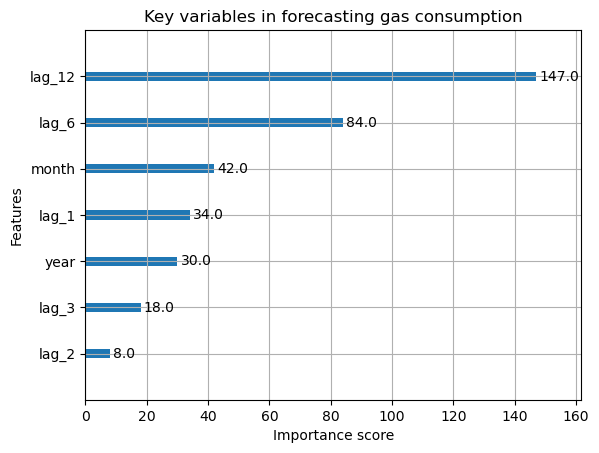

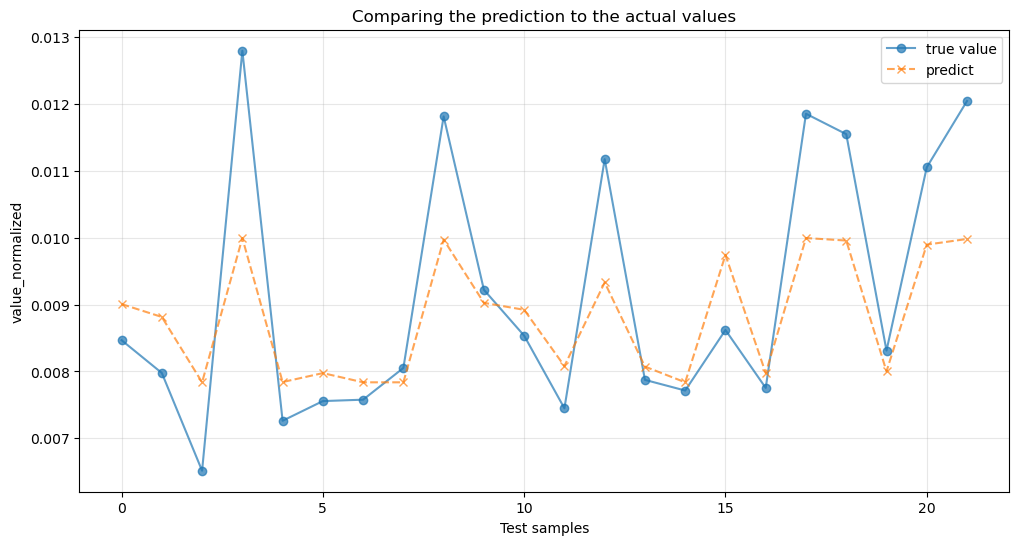

In [63]:

# تحميل وإعداد الداتا 
df = pd.read_csv('gas_cleann.csv')
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')

monthly = df.groupby(['date', 'year', 'month'])['value_normalized'].mean().reset_index()
monthly = monthly.rename(columns={'value_normalized': 'value_normalized'})

monthly = monthly.sort_values('date')

# إنشاء Lags شهرية
for lag in [1, 2, 3, 6, 12]:
    monthly[f'lag_{lag}'] = monthly['value_normalized'].shift(lag)

monthly = monthly.dropna().reset_index(drop=True)

# ====================== الميزات ======================
features = ['year', 'month', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12']
X = monthly[features]
y = monthly['value_normalized']

# تحويل الـ Target
y_transformed = np.sqrt(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

# ====================== أفضل نموذج ======================
model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    tree_method='hist'
)

model.fit(X_train, y_train, 
          eval_set=[(X_test, y_test)], 
          verbose=False)

# ====================== التقييم ======================
y_pred_trans = model.predict(X_test)
y_pred = y_pred_trans ** 2
y_test_orig = y_test ** 2

mae = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2 = r2_score(y_test_orig, y_pred)

print("="*65)
print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R²   : {r2:.4f}")
print(f"عدد الشهور: {len(monthly)}")
print("="*65)

# Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10)
plt.title('Key variables in forecasting gas consumption')
plt.show()

# رسم التنبؤ مقابل الواقع
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig.values, label='true value', marker='o', linestyle='-', alpha=0.7)
plt.plot(y_pred, label='predict', marker='x', linestyle='--', alpha=0.7)
plt.title('Comparing the prediction to the actual values')
plt.xlabel('Test samples')
plt.ylabel('value_normalized')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()